# DeepEval Commentary Analysis

Evaluates chess commentary quality using DeepEval metrics.  
Supports multi-file comparison across prompt configurations.

In [55]:
from __future__ import annotations
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR = Path("results")

## 1. File Selection

Specify result files and human-readable configuration labels in `FILES`.  
Accepts a single file or multiple files for side-by-side comparison.

In [56]:
# ── Configuration ────────────────────────────────────────────────────────────
# Key   = configuration label (appears on charts)
# Value = path to .jsonl results file
FILES: dict[str, str] = {
    "Unstructured": "results/deepeval_20260521_234440.jsonl",
    "Theory": "results/deepeval_20260522_022159.jsonl",
    "Alexander": "results/deepeval_20260522_012214.jsonl",
    "MIN": "results/deepeval_20260522_005724.jsonl",
    "FULL": "results/deepeval_20260524_142418.jsonl",
    "Haiku": "results/deepeval_20260521_204437.jsonl",
    "sonnet": "results/deepeval_20260522_000703.jsonl",
    # "gemma_bestMove": "results/deepeval_20260522_031824.jsonl",
    # "haiku": "results/deepeval_20260521_200926.jsonl",
    # "alexander_off": "results/deepeval_20260521_140609.jsonl",
    # "think_off_makogonov_off_tresholds_strict": "results/deepeval_20260521_133107.jsonl",
    # "think_on": "results/deepeval_20260521_125422.jsonl",
    #"gemma_v3": "results/deepeval_20260521_225540.jsonl",
    #"gemma_system_instruct_fix": "results/deepeval_20260521_223304.jsonl",
    # "gemma_baseline": "results/deepeval_20260521_222247.jsonl",
    # "qwen_full_new_metrics": "results/deepeval_20260521_215126.jsonl",
    # "qwen_full": "results/deepeval_20260521_213504.jsonl",
    
}

# Filter by game_id (None = all games)
GAME_FILTER: str | None = None  # e.g. "eval_trace_1779275077"
# ─────────────────────────────────────────────────────────────────────────────

In [57]:
def load_jsonl(path: str | Path) -> list[dict]:
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def build_df(records: list[dict], label: str) -> pd.DataFrame:
    rows = []
    for r in records:
        base = {
            "run": label,
            "trace_id": r["trace_id"],
            "game_id": r["game_id"],
            "move_number": r["move_number"],
            "san": r["san"],
            "color": r.get("color", "unknown"),
            "quality": r.get("quality", "unknown"),
            "commentary": r.get("commentary", ""),
        }
        for m in r.get("metrics", []):
            # strip " [GEval]" suffix for short names
            name = m["name"].replace(" [GEval]", "").replace(" ", "_")
            base[f"score_{name}"] = m["score"]
            base[f"reason_{name}"] = m.get("reason", "")
        rows.append(base)
    return pd.DataFrame(rows)


dfs: dict[str, pd.DataFrame] = {}
for label, path in FILES.items():
    records = load_jsonl(path)
    df = build_df(records, label)
    if GAME_FILTER:
        df = df[df["game_id"] == GAME_FILTER]
    dfs[label] = df
    print(f"{label}: {len(df)} records, games: {df['game_id'].nunique()}")

all_df = pd.concat(dfs.values(), ignore_index=True)
SCORE_COLS = [c for c in all_df.columns if c.startswith("score_")]
METRIC_NAMES = [c.replace("score_", "") for c in SCORE_COLS]
print(f"\nMetrics: {METRIC_NAMES}")

Unstructured: 52 records, games: 1
Theory: 52 records, games: 1
Alexander: 35 records, games: 1
MIN: 52 records, games: 1
FULL: 52 records, games: 1
Haiku: 52 records, games: 1
sonnet: 51 records, games: 1

Metrics: ['Accuracy', 'ConceptualDepth', 'InputCoverage', 'HallucinationControl']


## 2. Summary Table by Configuration

In [58]:
summary_rows = []
for label, df in dfs.items():
    row = {"run": label, "traces": len(df)}
    for col in SCORE_COLS:
        if col in df.columns:
            row[col.replace("score_", "")] = df[col].mean()
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index("run")
metric_cols = [c for c in summary.columns if c != "traces"]

display(
    summary.style
    .format({c: "{:.3f}" for c in metric_cols})
    .background_gradient(subset=metric_cols, cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption("Average metric scores (higher is better)")
)

,traces,Accuracy,ConceptualDepth,InputCoverage,HallucinationControl
run,,,,,
Unstructured,52,0.029,0.044,0.040,0.025
Theory,52,0.185,0.271,0.235,0.162
Alexander,35,0.186,0.251,0.257,0.194
MIN,52,0.204,0.283,0.287,0.190
FULL,52,0.188,0.198,0.221,0.160
Haiku,52,0.365,0.417,0.483,0.513
sonnet,51,0.394,0.641,0.633,0.578


## 3. Metric Comparison by Configuration (Radar + Bar)

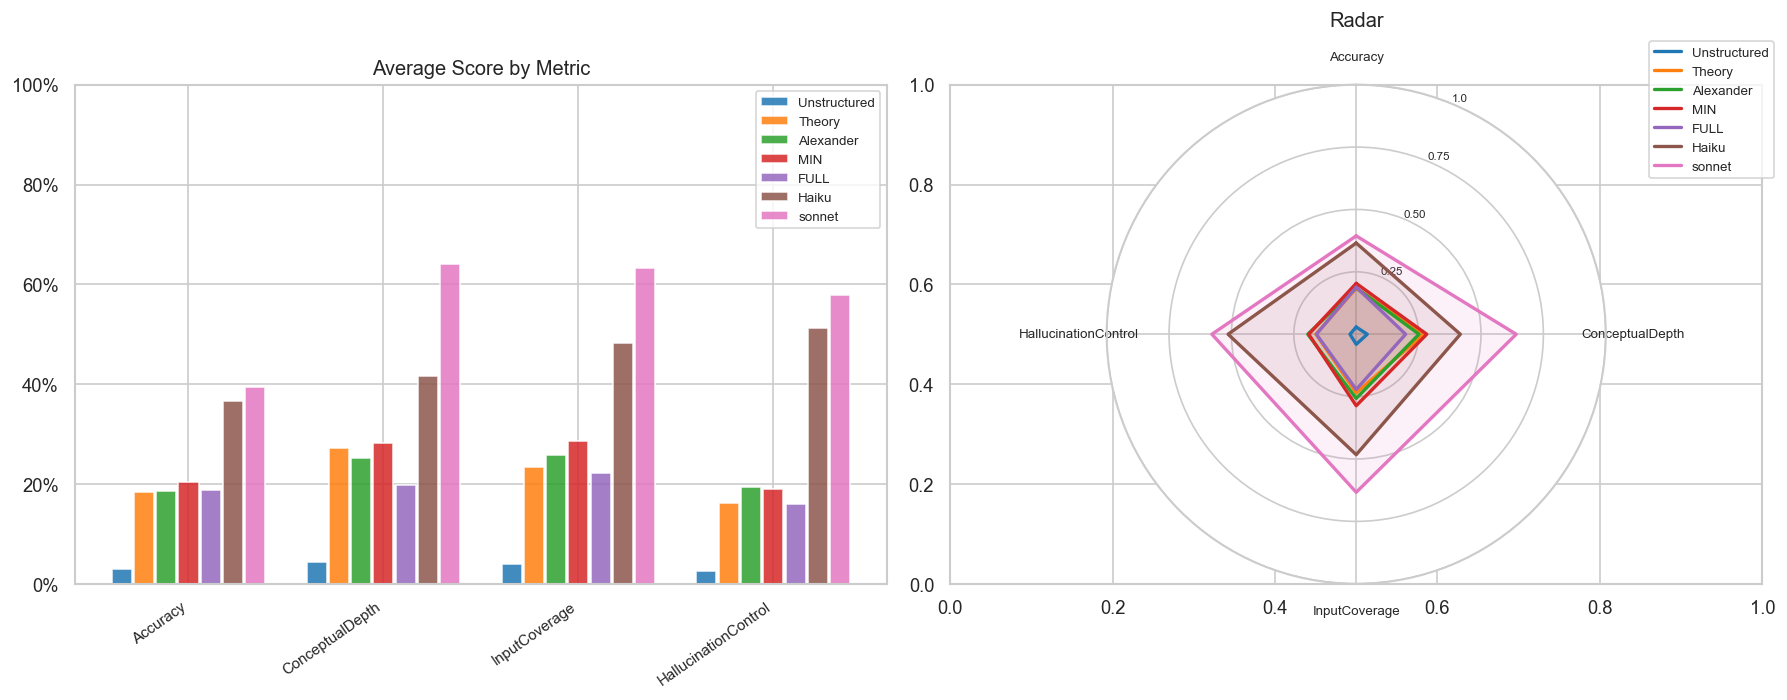

In [59]:
runs = list(dfs.keys())
colors = sns.color_palette("tab10", len(runs))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart ---
ax = axes[0]
x = np.arange(len(METRIC_NAMES))
width = 0.8 / max(len(runs), 1)
for i, (label, df) in enumerate(dfs.items()):
    means = [df[f"score_{m}"].mean() if f"score_{m}" in df.columns else 0 for m in METRIC_NAMES]
    ax.bar(x + i * width - width * (len(runs) - 1) / 2, means,
           width=width * 0.9, label=label, color=colors[i], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(METRIC_NAMES, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Average Score by Metric")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# --- Radar chart ---
ax2 = axes[1]
N = len(METRIC_NAMES)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

ax2 = plt.subplot(122, polar=True)
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(METRIC_NAMES, size=8)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], size=7)

for i, (label, df) in enumerate(dfs.items()):
    values = [df[f"score_{m}"].mean() if f"score_{m}" in df.columns else 0 for m in METRIC_NAMES]
    values += values[:1]
    ax2.plot(angles, values, linewidth=2, color=colors[i], label=label)
    ax2.fill(angles, values, alpha=0.1, color=colors[i])
ax2.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
ax2.set_title("Radar", pad=15)

plt.tight_layout()
plt.show()

## 4. Score Distribution by Metric (Box Plot)

/var/folders/v7/jd9nwf555hqg15pmncp612mc0000gn/T/ipykernel_79044/1144710295.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


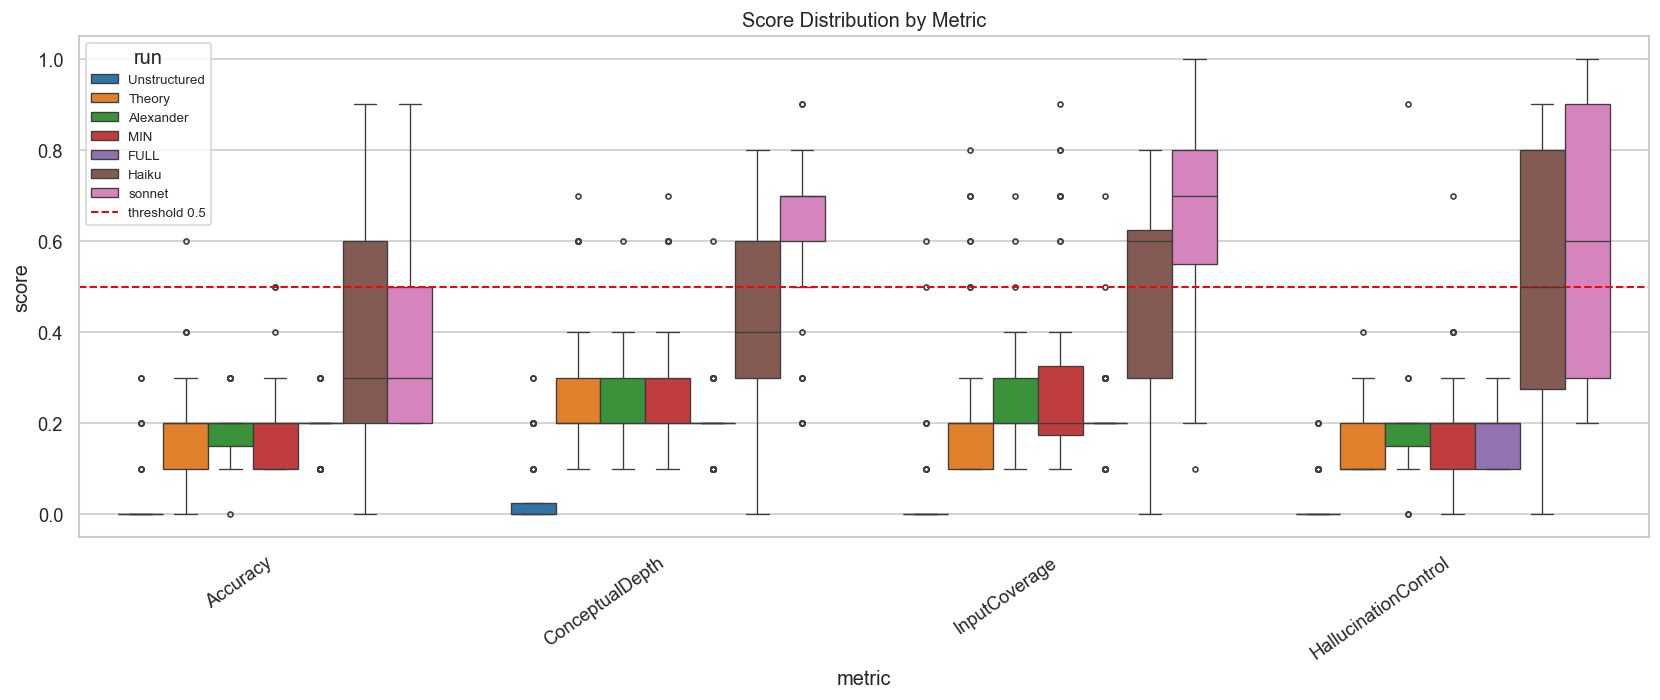

In [60]:
rows_long = []
for label, df in dfs.items():
    for m in METRIC_NAMES:
        col = f"score_{m}"
        if col in df.columns:
            for v in df[col].dropna():
                rows_long.append({"run": label, "metric": m, "score": v})
long_df = pd.DataFrame(rows_long)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=long_df, x="metric", y="score", hue="run",
    palette="tab10", linewidth=0.8, fliersize=3, ax=ax
)
ax.axhline(0.5, color="red", ls="--", lw=1.2, label="threshold 0.5")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Score Distribution by Metric")
ax.legend(title="run", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Score Trend over Move Number

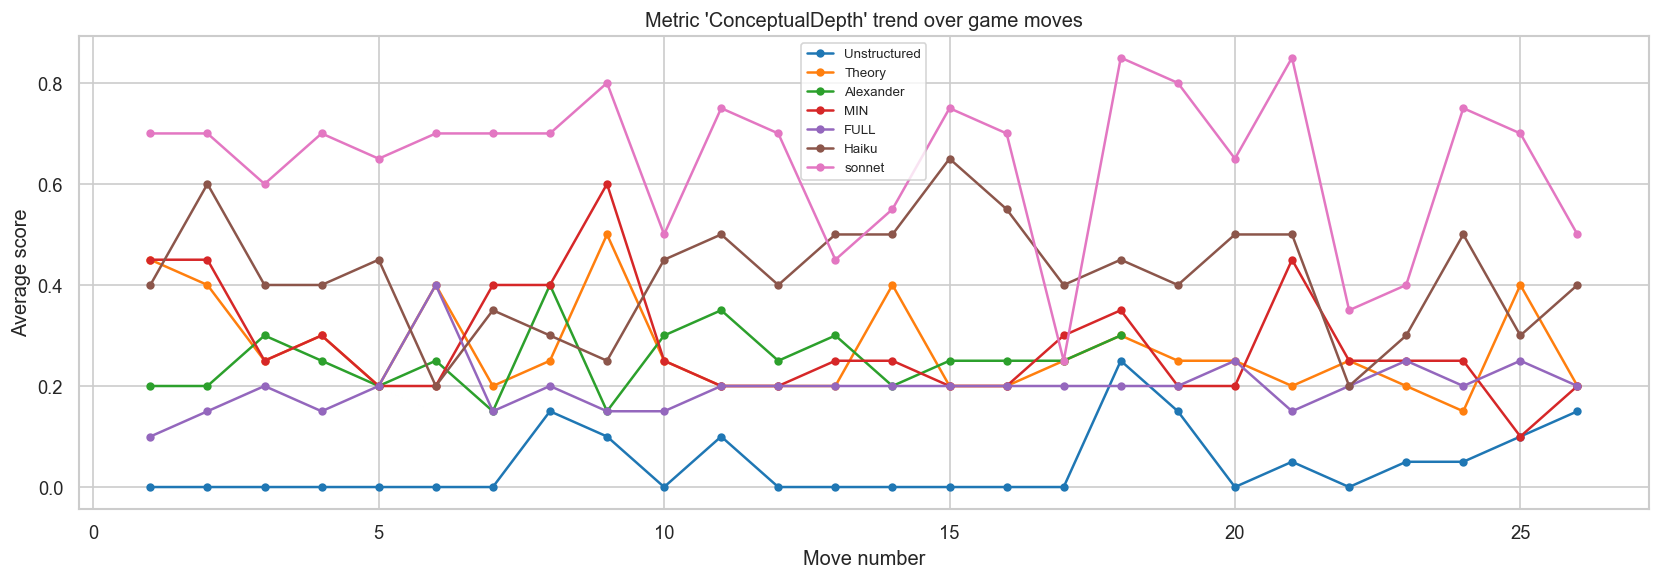

In [61]:
# Select a metric or 'overall_pass' to display
METRIC_FOR_TREND = METRIC_NAMES[1] if METRIC_NAMES else None

if METRIC_FOR_TREND:
    col = f"score_{METRIC_FOR_TREND}"
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (label, df) in enumerate(dfs.items()):
        if col not in df.columns:
            continue
        trend = df.groupby("move_number")[col].mean()
        ax.plot(trend.index, trend.values, marker="o", ms=4,
                label=label, color=colors[i])
    ax.set_xlabel("Move number")
    ax.set_ylabel("Average score")
    ax.set_title(f"Metric '{METRIC_FOR_TREND}' trend over game moves")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No metrics available.")

## 7. Heatmap of Average Scores (Configuration × Metric)

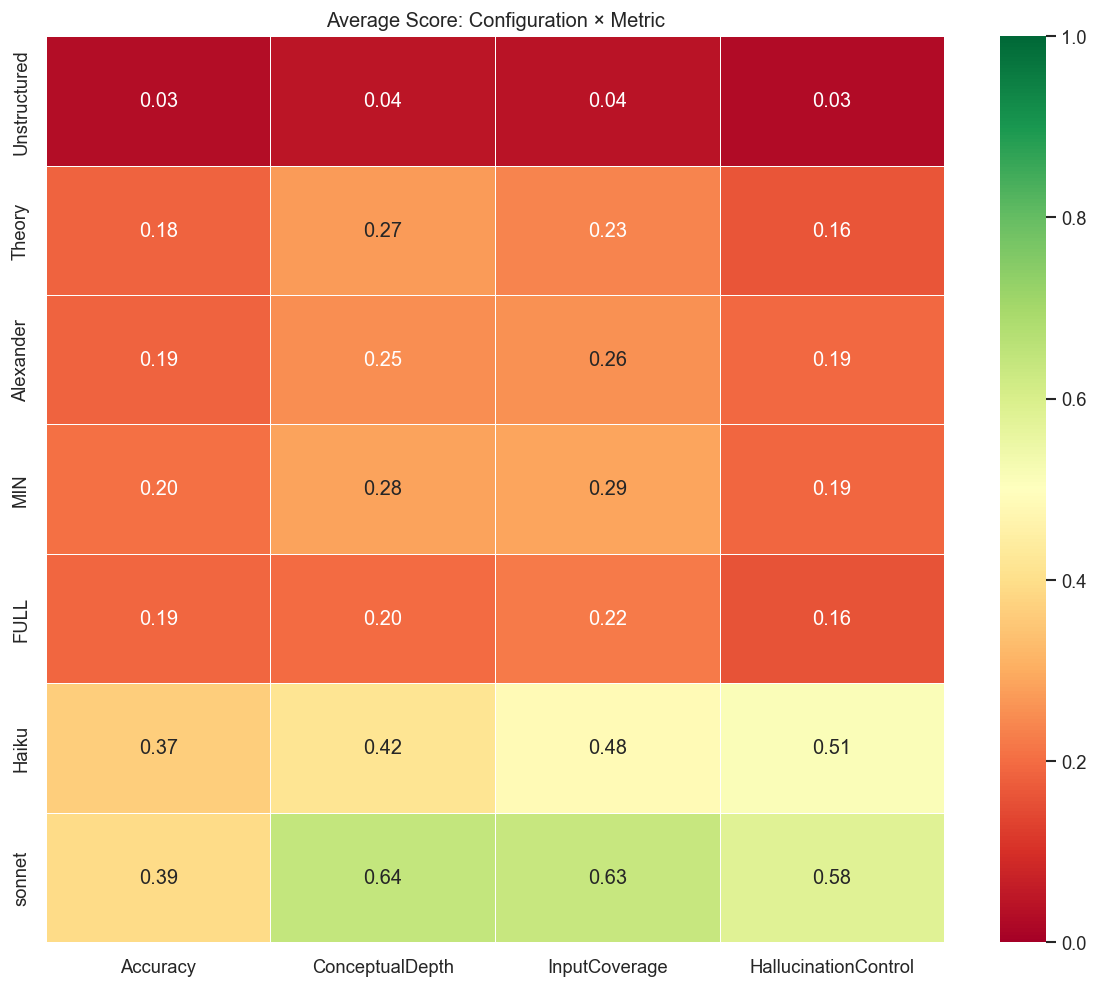

In [62]:
heat_data = {}
for label, df in dfs.items():
    heat_data[label] = {m: df[f"score_{m}"].mean() if f"score_{m}" in df.columns else np.nan
                        for m in METRIC_NAMES}

heat_df = pd.DataFrame(heat_data).T  # rows = runs, cols = metrics

fig, ax = plt.subplots(figsize=(max(10, len(METRIC_NAMES) * 1.3), max(3, len(dfs) * 1.2)))
sns.heatmap(
    heat_df, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title("Average Score: Configuration × Metric")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Worst Commentaries (Debug)

In [63]:
# Display N worst commentaries by average score for the selected run
TARGET_RUN = list(dfs.keys())[1]
TOP_N = 10

df = dfs[TARGET_RUN].copy()
df["avg_score"] = df[SCORE_COLS].mean(axis=1)
worst = df.nsmallest(TOP_N, "avg_score")[
    ["trace_id", "move_number", "san", "color", "quality", "avg_score"] + SCORE_COLS
]

display(
    worst.style
    .format({"avg_score": "{:.3f}", **{c: "{:.2f}" for c in SCORE_COLS}})
    .background_gradient(subset=["avg_score"] + SCORE_COLS, cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption(f"Top-{TOP_N} worst commentaries ({TARGET_RUN})")
)

,trace_id,move_number,san,color,quality,avg_score,score_Accuracy,score_ConceptualDepth,score_InputCoverage,score_HallucinationControl
13,eval_trace_theory__m7_Bd6_black_good,7,Bd6,black,good,0.100,0.00,0.20,0.10,0.10
47,eval_trace_theory__m24_Kh8_black_best,24,Kh8,black,best,0.100,0.10,0.10,0.10,0.10
1,eval_trace_theory__m1_f5_black_good,1,f5,black,good,0.125,0.10,0.20,0.10,0.10
9,eval_trace_theory__m5_Ne4_black_excellent,5,Ne4,black,excellent,0.125,0.10,0.20,0.10,0.10
19,eval_trace_theory__m10_Qxf2_black_best,10,Qxf2,black,best,0.125,0.10,0.20,0.10,0.10
21,eval_trace_theory__m11_Qxd4+_black_best,11,Qxd4+,black,best,0.125,0.10,0.20,0.10,0.10
24,eval_trace_theory__m13_cxd5_white_excellent,13,cxd5,white,excellent,0.125,0.10,0.20,0.10,0.10
27,eval_trace_theory__m14_Be6_black_excellent,14,Be6,black,excellent,0.125,0.10,0.20,0.10,0.10
29,eval_trace_theory__m15_Nb4_black_blunder,15,Nb4,black,blunder,0.125,0.10,0.20,0.10,0.10
31,eval_trace_theory__m16_Nxd3_black_best,16,Nxd3,black,best,0.125,0.10,0.20,0.10,0.10


In [64]:
best = df.nlargest(TOP_N, "avg_score")[
    ["trace_id", "move_number", "san", "color", "quality", "avg_score"] + SCORE_COLS
]

display(
    best.style
    .format({"avg_score": "{:.3f}", **{c: "{:.2f}" for c in SCORE_COLS}})
    .background_gradient(subset=["avg_score"] + SCORE_COLS, cmap="RdYlGn", vmin=0, vmax=1)
    .set_caption(f"Top-{TOP_N} best commentaries ({TARGET_RUN})")
)

,trace_id,move_number,san,color,quality,avg_score,score_Accuracy,score_ConceptualDepth,score_InputCoverage,score_HallucinationControl
2,eval_trace_theory__m2_Nf3_white_best,2,Nf3,white,best,0.500,0.40,0.60,0.80,0.20
16,eval_trace_theory__m9_Kd1_white_mistake,9,Kd1,white,mistake,0.500,0.40,0.60,0.70,0.30
0,eval_trace_theory__m1_d4_white_good,1,d4,white,good,0.475,0.30,0.70,0.70,0.20
48,eval_trace_theory__m25_Qxb7_white_blunder,25,Qxb7,white,blunder,0.450,0.30,0.60,0.60,0.30
26,eval_trace_theory__m14_Nc3_white_best,14,Nc3,white,best,0.450,0.60,0.60,0.20,0.40
17,eval_trace_theory__m9_Nf2+_black_inaccuracy,9,Nf2+,black,inaccuracy,0.400,0.40,0.40,0.50,0.30
6,eval_trace_theory__m4_Bg5_white_excellent,4,Bg5,white,excellent,0.350,0.30,0.40,0.50,0.20
11,eval_trace_theory__m6_e6_black_best,6,e6,black,best,0.325,0.20,0.60,0.20,0.30
30,eval_trace_theory__m16_Rc1_white_blunder,16,Rc1,white,blunder,0.325,0.20,0.20,0.70,0.20
34,eval_trace_theory__m18_Bh3_white_mistake,18,Bh3,white,mistake,0.325,0.20,0.30,0.60,0.20


## 9. Detailed Commentary Inspection

In [65]:
# Paste a trace_id to inspect it in detail
INSPECT_TRACE = worst.iloc[0]["trace_id"] if not worst.empty else ""
INSPECT_RUN   = TARGET_RUN

row = dfs[INSPECT_RUN][dfs[INSPECT_RUN]["trace_id"] == INSPECT_TRACE]
if row.empty:
    print(f"Trace '{INSPECT_TRACE}' not found in {INSPECT_RUN}")
else:
    row = row.iloc[0]
    print(f"=== {INSPECT_TRACE} ===")
    print(f"Move #{row['move_number']} {row['san']} ({row['color']}, {row['quality']})")
    print()
    print("─── Commentary ───")
    print(row["commentary"])
    print()
    for m in METRIC_NAMES:
        score = row.get(f"score_{m}", "n/a")
        reason = row.get(f"reason_{m}", "")
        print(f"{m}: {score:.2f}" if isinstance(score, float) else f"{m}: {score}")
        if reason:
            import textwrap
            for line in textwrap.wrap(reason, 100):
                print(f"    {line}")
        print()

=== eval_trace_theory__m7_Bd6_black_good ===
Move #7 Bd6 (black, good)

─── Commentary ───
White has established a solid pawn structure with the move d6, aiming for a positional advantage. The black knight’s attempt to challenge the center was ultimately unsuccessful, highlighting the relative lack of immediate threat.  The exchange suggests a cautious approach, maintaining a balanced position where White retains control of the central squares.

Accuracy: 0.00
    The response fails on multiple evaluation criteria. Step 1: The played move was Black's bishop to
    d6, but the output incorrectly describes 'White has established a solid pawn structure with the move
    d6,' misidentifying both the moving piece (pawn vs. bishop) and the side that played it (White vs.
    Black). Step 2: The engine's preferred move (Black's knight captures knight on e5) does not appear
    anywhere in the output. Step 3: The evaluation direction is inverted—the input states a 'small gain
    for White' (Wh

## 10. Score Delta between Configurations (Pairwise)

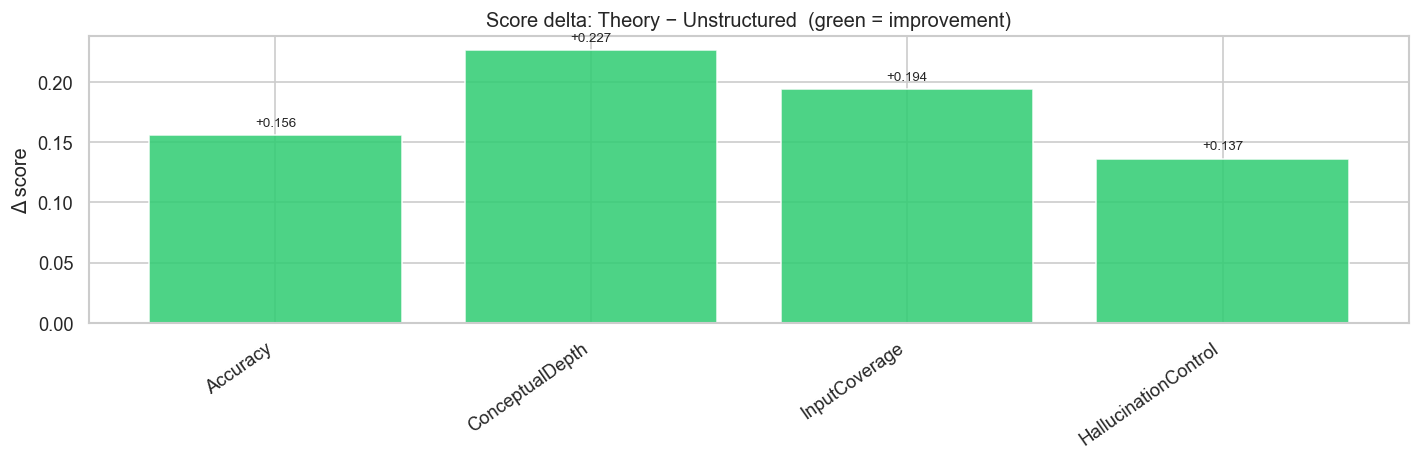

In [66]:
if len(dfs) >= 2:
    run_names = list(dfs.keys())
    BASE_RUN = run_names[0]
    CMP_RUN  = run_names[1]

    base_means = {m: dfs[BASE_RUN][f"score_{m}"].mean() for m in METRIC_NAMES if f"score_{m}" in dfs[BASE_RUN].columns}
    cmp_means  = {m: dfs[CMP_RUN][f"score_{m}"].mean()  for m in METRIC_NAMES if f"score_{m}" in dfs[CMP_RUN].columns}

    deltas = {m: cmp_means.get(m, 0) - base_means.get(m, 0) for m in METRIC_NAMES}

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(METRIC_NAMES))
    bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in deltas.values()]
    ax.bar(x, list(deltas.values()), color=bar_colors, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_NAMES, rotation=35, ha="right")
    ax.set_title(f"Score delta: {CMP_RUN} − {BASE_RUN}  (green = improvement)")
    ax.set_ylabel("Δ score")
    for xi, v in zip(x, deltas.values()):
        ax.text(xi, v + (0.005 if v >= 0 else -0.012), f"{v:+.3f}",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Add a second file to FILES to enable comparison.")